In [2]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
data = pd.read_csv("../data/Mall_Customers.csv")
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [5]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
x = data.drop(columns=["CustomerID"])
x.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [7]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.cluster import KMeans

num_features = x.select_dtypes(include=["int64"]).columns
cat_features = x.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer([
    ("num",StandardScaler(),num_features),
    ("cat",OneHotEncoder(drop="first"),cat_features)
])

C:\Users\nigam\AppData\Local\Temp\ipykernel_21044\268127758.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = x.select_dtypes(include=["object"]).columns


In [8]:

wcss = []

for k in range(1,11):
    pipe = Pipeline([
        ("preprocessor",preprocessor),
        ("KMeans",KMeans(n_clusters=k,random_state=42))
    ])
    
    pipe.fit(x)
    wcss.append(pipe["KMeans"].inertia_)

wcss    

[649.2799999999999,
 438.52241155677746,
 345.20503469910585,
 254.36171423484492,
 216.78490151651036,
 181.9514362434146,
 171.37266048943812,
 153.29724063982397,
 142.71846488584742,
 133.32664005446085]

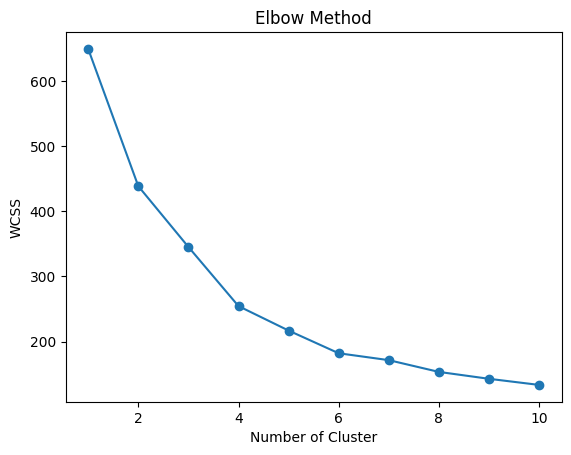

In [9]:
plt.plot(range(1,11),wcss,marker="o")
plt.xlabel("Number of Cluster")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [10]:
pipe = Pipeline([
    ("preprocessor",preprocessor),
    ("KMeans",KMeans(n_clusters=6,random_state=42))
])

pipe.fit(x)
cluster = pipe.predict(x)
data["Cluster"] = cluster

In [11]:
data

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,4
2,3,Female,20,16,6,2
3,4,Female,23,16,77,4
4,5,Female,31,17,40,2
...,...,...,...,...,...,...
195,196,Female,35,120,79,1
196,197,Female,45,126,28,3
197,198,Male,32,126,74,1
198,199,Male,32,137,18,3


In [14]:
data.groupby("Cluster").mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,83.777778,56.333333,54.266667,49.066667
1,162.000000,32.692308,86.538462,82.128205
2,23.190476,45.523810,26.285714,19.380952
3,164.529412,41.264706,88.500000,16.764706
4,22.130435,25.000000,25.260870,77.608696
5,90.052632,27.000000,56.657895,49.131579


In [ ]:
from sklearn.decomposition import PCA

x_preprocessed = pipe["preprocessor"].transform(x)

pca = PCA(n_components=2)

X_PCA = pca.fit_transform(x_preprocessed)

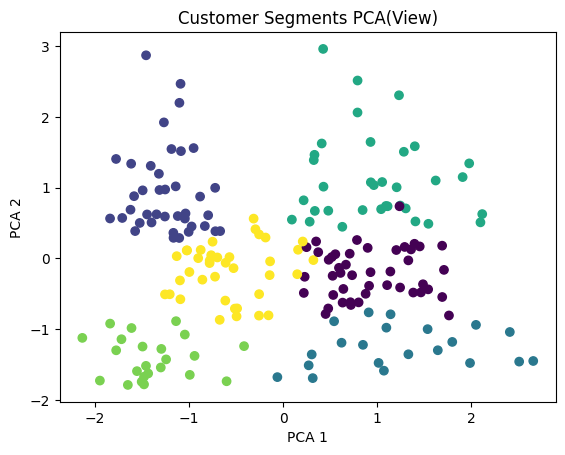

In [ ]:
plt.scatter(X_PCA[:,0],X_PCA[:,1],c=cluster)
plt.title("Customer Segments PCA(View)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()